# Treinamento Comparativo: CNN Customizada (Baseline Absoluto)

## Objetivo
Antes de explorar arquiteturas profundas com *Transfer Learning* (como VGG16 e ResNet50), este notebook estabelece um **baseline absoluto** construindo uma Rede Neural Convolucional (CNN) clássica e leve totalmente do zero. O intuito é avaliar como uma arquitetura simples performa no FER2013 sem o peso computacional de modelos complexos.

## Dados e Pré-processamento
* **Dataset:** FER2013 (*In-the-wild*).
* **Imagens:** Mantidas no formato nativo `48x48` em **tons de cinza** (1 canal de cor), economizando processamento.
* **Normalização:** Escalonamento manual dos pixels de `0-255` para `0-1` através da camada `Rescaling`.

## Arquitetura da Rede
Rede desenvolvida do zero para extração direta de características locais:
1. **Bloco 1:** `Conv2D` (32 filtros) + `MaxPooling2D`
2. **Bloco 2:** `Conv2D` (64 filtros) + `MaxPooling2D`
3. **Classificador:** `Flatten` -> `Dense` (64 neurônios, ativação *ReLU*) -> `Dense` (7 classes, ativação *Softmax*)

## Registro de Experimento
Acompanhamento contínuo das métricas com salvamento automático em `historico_cnn_customizada.csv` e proteção do melhor conjunto de pesos no arquivo `melhor_modelo_cnn_customizada.keras`.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint # NOVO: Importando os callbacks
import matplotlib.pyplot as plt

# 1. Definindo os caminhos e parâmetros básicos
caminho_treino = '../../data/raw/fer2013/train'
caminho_teste = '../../data/raw/fer2013/test'
tamanho_lote = 32 # Quantas imagens a IA vê por vez
tamanho_imagem = (48, 48) # Tamanho padrão do FER2013

print("Carregando dados de treinamento...")
dados_treino = tf.keras.utils.image_dataset_from_directory(
    caminho_treino,
    color_mode="grayscale", # Nossas imagens são em tons de cinza
    image_size=tamanho_imagem,
    batch_size=tamanho_lote
)

print("\nCarregando dados de validação (teste)...")
dados_teste = tf.keras.utils.image_dataset_from_directory(
    caminho_teste,
    color_mode="grayscale",
    image_size=tamanho_imagem,
    batch_size=tamanho_lote
)

# 2. Construindo a CNN "Baseline" (A Primeira Sinapse)
modelo = models.Sequential([
    # Camada de entrada que normaliza os pixels (de 0-255 para 0-1)
    layers.Rescaling(1./255, input_shape=(48, 48, 1)),
    
    # Primeira extração de características (Convolução + Pooling)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Segunda extração
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Achatando os dados para a tomada de decisão
    layers.Flatten(),
    
    # Camada de raciocínio
    layers.Dense(64, activation='relu'),
    
    # Camada de saída: 7 neurônios (um para cada emoção)
    layers.Dense(7, activation='softmax')
])

# 3. Compilando o modelo
modelo.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Resumo visual da arquitetura
modelo.summary()

# ---------------------------------------------------------
# NOVO: Configurando os Salvamentos Automáticos (Callbacks)
# ---------------------------------------------------------
csv_logger_cnn = CSVLogger('../../reports/historico_cnn_customizada.csv', append=True)

checkpoint_cnn = ModelCheckpoint(
    'melhor_modelo_cnn_customizada.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

# 4. Treinamento
print("\nIniciando o treinamento. Pegue um café, a CNN está aprendendo...")
historico = modelo.fit(
    dados_treino,
    validation_data=dados_teste,
    epochs=30, # Ajustado para 30 para manter o padrão comparativo com as outras redes
    callbacks=[csv_logger_cnn, checkpoint_cnn] # <-- Injetamos os salvadores aqui!
)

print("\nMissão Cumprida: O modelo completou o ciclo de aprendizado e os dados foram salvos!")

Carregando dados de treinamento...
Found 28709 files belonging to 7 classes.

Carregando dados de validação (teste)...
Found 7178 files belonging to 7 classes.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 48, 48, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 46, 46, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 23, 23, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 10, 10, 64)       0         
 2D)                        

# Avaliação Profunda: Matriz de Confusão e Relatório de Classificação

## Objetivo
Após identificar que a CNN Customizada (Baseline) apresentou o melhor desempenho geral, mas sofreu com *overfitting* a partir da 5ª época, o próximo passo é investigar o impacto do desbalanceamento das classes. 

## Ferramentas de Diagnóstico
* **Matriz de Confusão:** Permite visualizar de forma cruzada onde o modelo está "se confundindo". Qual emoção ele chuta quando não sabe a resposta? Ele confunde "Tristeza" com "Neutro"?
* **Classification Report:** Detalha métricas cruciais além da acurácia global:
  * **Precision (Precisão):** De todas as vezes que o modelo disse que era "Feliz", quantas ele realmente acertou?
  * **Recall (Sensibilidade):** De todos os rostos que *realmente* eram "Nojo", quantos o modelo conseguiu encontrar?
  * **F1-Score:** A média harmônica entre Precision e Recall (a métrica definitiva para datasets desbalanceados).

Carregando dados de teste para avaliação...
Found 7178 files belonging to 7 classes.

Despertando o 'cérebro' da CNN Customizada...
Analisando as imagens de teste. Aguarde...
225/225 [==============================] - 2s 8ms/step


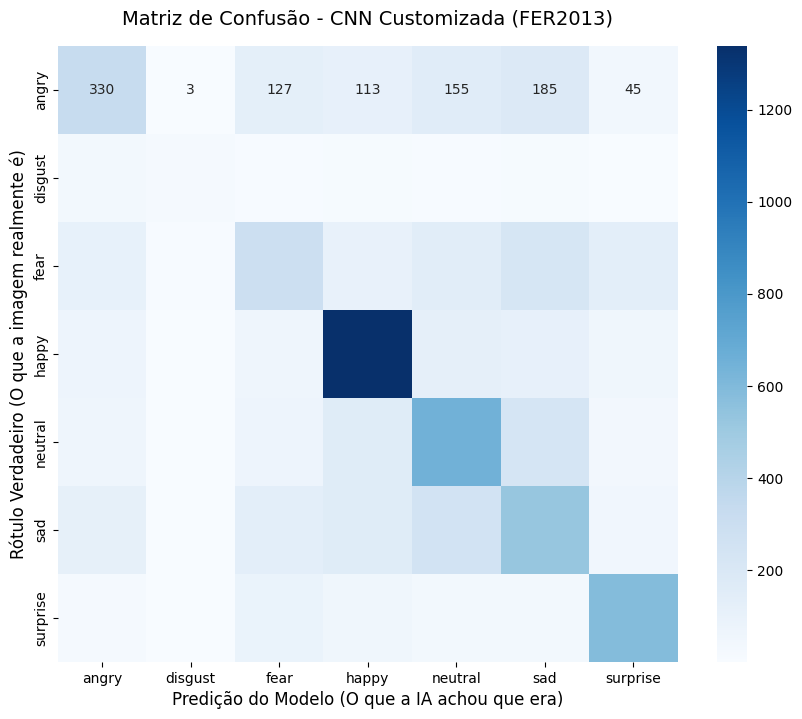


 RELATÓRIO DE CLASSIFICAÇÃO (Métricas por Classe)
              precision    recall  f1-score   support

       angry       0.43      0.34      0.38       958
     disgust       0.54      0.23      0.32       111
        fear       0.37      0.29      0.33      1024
       happy       0.69      0.75      0.72      1774
     neutral       0.47      0.53      0.50      1233
         sad       0.40      0.42      0.41      1247
    surprise       0.64      0.71      0.67       831

    accuracy                           0.52      7178
   macro avg       0.51      0.47      0.48      7178
weighted avg       0.51      0.52      0.52      7178



In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Parâmetros e Caminhos
caminho_teste = '../../data/raw/fer2013/test'
tamanho_lote = 32
tamanho_imagem = (48, 48)

# 2. Carregando dados de teste SEM EMBARALHAR (shuffle=False)
print("Carregando dados de teste para avaliação...")
dados_teste = tf.keras.utils.image_dataset_from_directory(
    caminho_teste,
    color_mode="grayscale", # Usamos grayscale na CNN customizada
    image_size=tamanho_imagem,
    batch_size=tamanho_lote,
    shuffle=False # MUITO IMPORTANTE: Garante que a ordem das imagens bata com a ordem das predições
)

nome_classes = dados_teste.class_names

# 3. Carregando o modelo salvo
print("\nDespertando o 'cérebro' da CNN Customizada...")
modelo = tf.keras.models.load_model('melhor_modelo_cnn_customizada.keras')

# 4. Extraindo rótulos reais e fazendo predições
print("Analisando as imagens de teste. Aguarde...")
rotulos_verdadeiros = np.concatenate([y for x, y in dados_teste], axis=0)

# O predict retorna as probabilidades (7 valores por imagem). 
# O argmax pega o índice da emoção com maior probabilidade.
predicoes_prob = modelo.predict(dados_teste)
predicoes = np.argmax(predicoes_prob, axis=1)

# 5. Gerando a Matriz de Confusão
matriz = confusion_matrix(rotulos_verdadeiros, predicoes)

plt.figure(figsize=(10, 8))
# Desenhando um mapa de calor bonito para a matriz
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nome_classes, yticklabels=nome_classes)

plt.title('Matriz de Confusão - CNN Customizada (FER2013)', fontsize=14, pad=15)
plt.ylabel('Rótulo Verdadeiro (O que a imagem realmente é)', fontsize=12)
plt.xlabel('Predição do Modelo (O que a IA achou que era)', fontsize=12)

# Salva a matriz em alta qualidade para o documento do TCC
plt.savefig('../../reports/figures/matriz_confusao_cnn_customizada.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Imprimindo o Relatório de Classificação Detalhado
print("\n" + "="*55)
print(" RELATÓRIO DE CLASSIFICAÇÃO (Métricas por Classe)")
print("="*55)
print(classification_report(rotulos_verdadeiros, predicoes, target_names=nome_classes))

# Experimento de Mitigação: CNN com Class Weights

## Objetivo
A avaliação do *baseline* da CNN customizada revelou um claro viés de aprendizado causado pelo severo desbalanceamento do dataset FER2013. A rede atingiu alto índice de acerto na classe "Happy" (majoritária), mas apresentou quase cegueira preditiva para a classe "Disgust" (minoritária). Este experimento visa forçar a rede a penalizar mais severamente os erros cometidos nas classes raras, sem a necessidade imediata de geração de dados sintéticos (SMOTE).

## Modificações na Abordagem
* **Arquitetura:** Mantida estritamente idêntica à CNN Customizada (Baseline) para garantir um controle isolado da variável de balanceamento.
* **Técnica de Penalização (`class_weight`):** Utilização do algoritmo `compute_class_weight` do *Scikit-learn* para calcular pesos inversamente proporcionais à frequência das classes. O otimizador agora multiplicará a perda (*loss*) pelo peso da classe, "obrigando" os gradientes a se ajustarem às emoções menos representadas.

## Registro de Experimento
Para não sobrescrever a prova do problema original, este experimento gerará arquivos independentes: `historico_cnn_balanceada.csv` e `melhor_modelo_cnn_balanceada.keras`.

In [4]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# 1. Definindo os caminhos e parâmetros básicos
caminho_treino = '../../data/raw/fer2013/train'
caminho_teste = '../../data/raw/fer2013/test'
tamanho_lote = 32 
tamanho_imagem = (48, 48)

print("Carregando dados de treinamento e validação...")
dados_treino = tf.keras.utils.image_dataset_from_directory(
    caminho_treino, color_mode="grayscale", image_size=tamanho_imagem, batch_size=tamanho_lote)
dados_teste = tf.keras.utils.image_dataset_from_directory(
    caminho_teste, color_mode="grayscale", image_size=tamanho_imagem, batch_size=tamanho_lote)

# ---------------------------------------------------------
# 2. NOVO: Cálculo dos Pesos de Classe Matemáticos
# ---------------------------------------------------------
print("\nExtraindo rótulos reais para calcular a penalização (isso leva alguns segundos)...")
# Desempacota as respostas reais do dataset de treinamento
rotulos_treino = np.concatenate([y for x, y in dados_treino], axis=0)

# Calcula o peso ideal (Amostras da minoria ganham peso alto, maioria ganha peso baixo)
pesos_calculados = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(rotulos_treino),
    y=rotulos_treino
)

# Transforma a lista de pesos num dicionário que o TensorFlow consegue ler
pesos_dicionario = dict(enumerate(pesos_calculados))

print("\nPesos atribuídos para a função Loss:")
for classe, peso in zip(dados_treino.class_names, pesos_calculados):
    print(f" - {classe}: {peso:.2f}x")

# ---------------------------------------------------------
# 3. Construindo a CNN "Baseline" (Mesma arquitetura)
# ---------------------------------------------------------
modelo_balanceado = models.Sequential([
    layers.Rescaling(1./255, input_shape=(48, 48, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(7, activation='softmax')
])

modelo_balanceado.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks com Nomes Novos (Blindando os dados anteriores)
csv_logger = CSVLogger('historico_cnn_balanceada.csv', append=True)
checkpoint = ModelCheckpoint(
    'melhor_modelo_cnn_balanceada.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

# 5. Treinamento
print("\nIniciando o treinamento BALANCEADO...")
# Dica: É normal que a acurácia geral inicial caia um pouco, pois a rede vai 
# errar mais tentando "aprender do jeito difícil" as emoções raras.
historico = modelo_balanceado.fit(
    dados_treino,
    validation_data=dados_teste,
    epochs=30,
    class_weight=pesos_dicionario, # <-- A intervenção matemática acontece aqui!
    callbacks=[csv_logger, checkpoint]
)

Carregando dados de treinamento e validação...
Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

Extraindo rótulos reais para calcular a penalização (isso leva alguns segundos)...

Pesos atribuídos para a função Loss:
 - angry: 1.03x
 - disgust: 9.41x
 - fear: 1.00x
 - happy: 0.57x
 - neutral: 0.83x
 - sad: 0.85x
 - surprise: 1.29x

Iniciando o treinamento BALANCEADO...
Epoch 1/30
895/898 [============================>.] - ETA: 0s - loss: 1.7980 - accuracy: 0.2791
Epoch 1: val_accuracy improved from -inf to 0.34327, saving model to melhor_modelo_cnn_balanceada.keras
898/898 [==============================] - 18s 20ms/step - loss: 1.7970 - accuracy: 0.2793 - val_loss: 1.6790 - val_accuracy: 0.3433
Epoch 2/30
895/898 [============================>.] - ETA: 0s - loss: 1.5369 - accuracy: 0.4081
Epoch 2: val_accuracy improved from 0.34327 to 0.39872, saving model to melhor_modelo_cnn_balanceada.keras
898/898 [==============================] - 18s 20ms/step 

# Experimento de Aumento de Dados: Balanceamento com SMOTE

## Objetivo
A tentativa anterior de mitigar o viés utilizando penalizações matemáticas (*Class Weights*) resultou em um *overfitting* severo, onde a rede memorizou as raras imagens da classe minoritária. Seguindo a recomendação do orientador, este experimento aplica o **SMOTE (Synthetic Minority Over-sampling Technique)**. O objetivo é gerar imagens sintéticas para as classes sub-representadas (como "Nojo" e "Medo") através da interpolação de pixels, nivelando a quantidade de exemplos no conjunto de treinamento para que a rede aprenda padrões generalistas.

## Modificações na Abordagem
* **Pré-processamento Vetorial:** Extração e "achatamento" (Flatten) das matrizes 48x48 do Keras para arrays 1D, formato exigido pelo SMOTE.
* **Geração Sintética:** Aplicação do algoritmo para igualar o número de amostras de todas as emoções baseando-se na classe majoritária ("Happy").
* **Reconstrução Espacial:** Redimensionamento dos arrays 1D gerados de volta para tensores espaciais `(48, 48, 1)` para alimentar a CNN.
* **Arquitetura:** CNN Customizada (Baseline) mantida inalterada para isolar a variável de aumento de dados.

## Registro de Experimento
Geração independente dos arquivos `historico_cnn_smote.csv` e `melhor_modelo_cnn_smote.keras`.

In [5]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from imblearn.over_sampling import SMOTE

# 1. Definindo os caminhos e parâmetros básicos
caminho_treino = '../../data/raw/fer2013/train'
caminho_teste = '../../data/raw/fer2013/test'
tamanho_lote = 32 
tamanho_imagem = (48, 48)

print("Carregando dados nativos...")
dados_treino = tf.keras.utils.image_dataset_from_directory(
    caminho_treino, color_mode="grayscale", image_size=tamanho_imagem, batch_size=tamanho_lote)
dados_teste = tf.keras.utils.image_dataset_from_directory(
    caminho_teste, color_mode="grayscale", image_size=tamanho_imagem, batch_size=tamanho_lote)

# ---------------------------------------------------------
# 2. NOVO: O Pipeline do SMOTE
# ---------------------------------------------------------
print("\nExtraindo imagens para a memória (Isso pode levar um minuto)...")
# Extrai as imagens (X) e os rótulos (y) dos lotes do Keras
x_treino_lista = []
y_treino_lista = []
for imagens, rotulos in dados_treino:
    x_treino_lista.append(imagens.numpy())
    y_treino_lista.append(rotulos.numpy())

X_treino = np.concatenate(x_treino_lista, axis=0)
y_treino = np.concatenate(y_treino_lista, axis=0)

print(f"Formato original do Treino: {X_treino.shape}")

# Achatando as imagens (De 48x48x1 para 2304) para o SMOTE entender
num_amostras = X_treino.shape[0]
X_treino_achatado = X_treino.reshape((num_amostras, 48 * 48))

print("Aplicando o SMOTE para gerar imagens sintéticas...")
smote = SMOTE(random_state=42)
X_treino_smote_achatado, y_treino_smote = smote.fit_resample(X_treino_achatado, y_treino)

# Dobrando as imagens de volta para 48x48x1
X_treino_balanceado = X_treino_smote_achatado.reshape((-1, 48, 48, 1))

print(f"Formato NOVO do Treino balanceado: {X_treino_balanceado.shape}")
print("SMOTE concluído com sucesso!")

# ---------------------------------------------------------
# 3. Construindo a CNN "Baseline" (Mesma arquitetura)
# ---------------------------------------------------------
modelo_smote = models.Sequential([
    layers.Rescaling(1./255, input_shape=(48, 48, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(7, activation='softmax')
])

modelo_smote.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para salvar esse experimento
csv_logger = CSVLogger('historico_cnn_smote.csv', append=True)
checkpoint = ModelCheckpoint(
    'melhor_modelo_cnn_smote.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

# 5. Treinamento
print("\nIniciando o treinamento com os dados sintéticos do SMOTE...")
# Como agora temos arrays numpy brutos (X_treino_balanceado), o 'fit' gerencia o tamanho do lote
historico = modelo_smote.fit(
    X_treino_balanceado, 
    y_treino_smote,
    validation_data=dados_teste, # O teste continua sendo o original, sem dados sintéticos!
    epochs=30,
    batch_size=32,
    callbacks=[csv_logger, checkpoint]
)

Carregando dados nativos...
Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

Extraindo imagens para a memória (Isso pode levar um minuto)...
Formato original do Treino: (28709, 48, 48, 1)
Aplicando o SMOTE para gerar imagens sintéticas...
Formato NOVO do Treino balanceado: (50505, 48, 48, 1)
SMOTE concluído com sucesso!

Iniciando o treinamento com os dados sintéticos do SMOTE...
Epoch 1/30
1578/1579 [============================>.] - ETA: 0s - loss: 1.4810 - accuracy: 0.4348
Epoch 1: val_accuracy improved from -inf to 0.46392, saving model to melhor_modelo_cnn_smote.keras
1579/1579 [==============================] - 26s 16ms/step - loss: 1.4809 - accuracy: 0.4348 - val_loss: 1.4121 - val_accuracy: 0.4639
Epoch 2/30
1578/1579 [============================>.] - ETA: 0s - loss: 1.1203 - accuracy: 0.5819
Epoch 2: val_accuracy improved from 0.46392 to 0.49805, saving model to melhor_modelo_cnn_smote.keras
1579/1579 [==============================] - 27s 1

# Experimento de Mitigação: CNN com Augmentation e Pesos de Classe

## Objetivo
A aplicação isolada de pesos matemáticos (*Class Weights*) forçou a rede a prestar atenção nas classes minoritárias, mas resultou em memorização (overfitting) pela falta de variedade visual. Este experimento resolve o problema introduzindo **Data Augmentation Dinâmico**. Ao aplicar rotações, zoom e espelhamento aleatórios nas imagens a cada época, garantimos que a rede nunca veja exatamente a mesma foto minoritária duas vezes, forçando-a a aprender as características geométricas universais das expressões.

## Modificações na Abordagem
* **Camada de Aumento de Dados:** Inserção de um bloco `Sequential` no topo da rede com `RandomFlip`, `RandomRotation` e `RandomZoom`.
* **Sinergia:** O otimizador penaliza fortemente erros nas classes raras (via `class_weight`), mas as variações geométricas impedem que a rede decore os pixels de treino.
* **Dados Naturais:** Mantemos as imagens em `48x48` tons de cinza (grayscale).

In [6]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

caminho_treino = '../../data/raw/fer2013/train'
caminho_teste = '../../data/raw/fer2013/test'
tamanho_lote = 32 
tamanho_imagem = (48, 48)

print("Carregando dados (Grayscale)...")
dados_treino = tf.keras.utils.image_dataset_from_directory(
    caminho_treino, color_mode="grayscale", image_size=tamanho_imagem, batch_size=tamanho_lote)
dados_teste = tf.keras.utils.image_dataset_from_directory(
    caminho_teste, color_mode="grayscale", image_size=tamanho_imagem, batch_size=tamanho_lote)

print("\nCalculando Pesos de Classe...")
rotulos_treino = np.concatenate([y for x, y in dados_treino], axis=0)
pesos_calculados = compute_class_weight('balanced', classes=np.unique(rotulos_treino), y=rotulos_treino)
pesos_dicionario = dict(enumerate(pesos_calculados))

# 1. Pipeline de Augmentation Dinâmico
data_augmentation = models.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# 2. Arquitetura Customizada com Augmentation
modelo_aug = models.Sequential([
    layers.Rescaling(1./255, input_shape=(48, 48, 1)),
    data_augmentation, # O aumento acontece aqui, dentro da GPU!
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(7, activation='softmax')
])

modelo_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

csv_logger = CSVLogger('historico_cnn_aug_weights.csv', append=True)
checkpoint = ModelCheckpoint('melhor_modelo_cnn_aug.keras', monitor='val_accuracy', save_best_only=True, mode='max')

print("\nIniciando treinamento com Augmentation e Pesos...")
historico = modelo_aug.fit(
    dados_treino, validation_data=dados_teste, epochs=30,
    class_weight=pesos_dicionario, callbacks=[csv_logger, checkpoint]
)

Carregando dados (Grayscale)...
Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

Calculando Pesos de Classe...

Iniciando treinamento com Augmentation e Pesos...
Epoch 1/30
898/898 [==============================] - 24s 25ms/step - loss: 1.8923 - accuracy: 0.1982 - val_loss: 1.9090 - val_accuracy: 0.1923
Epoch 2/30
898/898 [==============================] - 22s 24ms/step - loss: 1.8126 - accuracy: 0.2431 - val_loss: 1.7718 - val_accuracy: 0.2689
Epoch 3/30
898/898 [==============================] - 23s 26ms/step - loss: 1.7210 - accuracy: 0.3181 - val_loss: 1.6577 - val_accuracy: 0.3612
Epoch 4/30
898/898 [==============================] - 24s 27ms/step - loss: 1.6531 - accuracy: 0.3565 - val_loss: 1.5258 - val_accuracy: 0.4223
Epoch 5/30
898/898 [==============================] - 22s 24ms/step - loss: 1.5886 - accuracy: 0.3827 - val_loss: 1.6072 - val_accuracy: 0.3877
Epoch 6/30
898/898 [==============================] - 20s 22ms/step - loss: 1.5479 